In [ ]:
import sys
import time
import serial
import  glob
from matplotlib import pyplot as plt
import numpy as np
import json

In [40]:
# Function to find the connected devices on available serial ports
def findDevice(question="hello", answer="",verbose=False, flush=True, timeout=5):
    """
    Attempts to find Ambit on any available serial port by sending 
    a 'question' string and looking for an 'answer' substring in the response.
    If no matching device is found on any port, implicitly return None

    :param question: The message to send to the device (default: "hello").
    :param answer: The substring we expect in the device's response (default: "").
    :param flush: Whether to flush the serial buffer before sending the question (default: True).
    :param timeout: The read timeout for the serial port in seconds (default: 1).
    :return: The port where the expected 'answer' is found, or None if not found.
    """
    
    def serial_ports():
        """ Lists serial port names

            :raises EnvironmentError:
                On unsupported or unknown platforms
            :returns:
                A list of the serial ports available on the system
        """
        if sys.platform.startswith('win'):
            ports = ['COM%s' % (i + 1) for i in range(256)]
        elif sys.platform.startswith('linux') or sys.platform.startswith('cygwin'):
            # this excludes your current terminal "/dev/tty"
            ports = glob.glob('/dev/tty[A-Za-z]*')
        elif sys.platform.startswith('darwin'):
            ports = glob.glob('/dev/tty.*')
        else:
            raise EnvironmentError('Unsupported platform')

        result = []
        for port in ports:
            try:
                s = serial.Serial(port)
                s.close()
                result.append(port)
            except (OSError, serial.SerialException):
                pass
        return result
    
    for port in serial_ports():     # Iterate through each potential serial port returned by 'serial_ports()'
        with serial.Serial(port, baudrate=115200, timeout=timeout) as ser:         # Open the serial port using a context manager to ensure it closes automatically
            # ser.dtr = False
            # ser.rts = False
            # If flush is True, clear any existing data in the buffer 
            # and give a short delay to stabilize
            time.sleep(0.5) # Short delay to allow the serial port to stabilize after opening
            if flush:
                #ser.flush()
                ser.reset_input_buffer()
                time.sleep(0.5)
        
            ser.write(question.encode()) # Encode and write the 'question' to the serial port
            time.sleep(0.5) # Allow some time for the device to respond
            
            msg = ser.readline().decode() # Read one line of response from the serial port, then decode it
            
            # If the expected 'answer' substring is in the device response, 
            # print and return the port
            print(f"Received message: {msg}")
            if answer in msg:
                print(f"Found device at: {port}, answer: {msg}")
                return port
    print("No matching device found.")
    return None  # If no matching device is found, return None

def get_par(port, raw=False):
    # read miniPar
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        if raw:
            ser.write("par_raw\n".encode())
        else:
            ser.write("par\n".encode())
        try:
            r = json.loads(ser.readline().decode().strip())
            par = float(next(iter(r.values()))) # get the first value from the dict
        except Exception as e:
            print(f"Error reading PAR value: {e}")
            par = None
        
        return par

def reset_miniPar(port):
# clear the calibration coefficient to default
    with serial.Serial(port, baudrate=115200) as ser:
        ser.write(f"cal_par_slope,1.0\n".encode())
        print(ser.readline().decode().strip())
    time.sleep(0.3)
    with serial.Serial(port, baudrate=115200) as ser:
        ser.write(f"cal_par_intercept,0.0\n".encode())
        print(ser.readline().decode().strip())

def get_MP_name(port, verbose=False):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        ser.write("get_name\n".encode())
        r = ser.readline()
        if verbose:
            print(f"Response from device: {r.decode().strip()}")
        returned_name = json.loads(r.decode()).get("device_name", "")
        return returned_name
    
def set_MP_name(port, name="miniPAR",verbose=False):
    # set Name mini Par
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        ser.write(f"set_name,{name}\n".encode())
        r = ser.readline()
        if verbose:
            print(f"Response from device: {r.decode()}")
        returned_name = json.loads(r.decode()).get("device_name", "")
        if(returned_name != name):
            print(f"Error setting {name}: {returned_name} returned")

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    return 1 - ss_res / ss_tot

def plot_data_and_fit(x, y, coeffs, r2, output=None, xlabel="x", ylabel="y"):
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, color="blue", label="Data points")

    x_sort = np.linspace(np.min(x), np.max(x), 300)
    y_fit = np.polyval(coeffs, x_sort)
    plt.plot(x_sort, y_fit, color="red", label=f"lin fit: {coeffs[0]:.4g}x + {coeffs[1]:.4g}   R2 = {r2:.8g}")

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Data and Linear Fit")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    if output:
        plt.savefig(output)
        print(f"Saved plot to {output}")
    plt.show()

In [41]:
# Initialize ports for MiniPAR
PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)

Received message: {"device":"MiniPAR","version":"1.1"}

Found device at: COM20, answer: {"device":"MiniPAR","version":"1.1"}



In [52]:
reset_miniPar(PORT_MINIPAR)

{"calibration":{"slope":1.00}}
{"calibration":{"intercept":0.00}}


In [ ]:
print("Raw values:", get_par(PORT_MINIPAR, raw=True))
time.sleep(0.5) # otherwise might overcome serial 
print("Calibrated values:", get_par(PORT_MINIPAR, raw=False))


Raw values: 0.53
Calibrated values: 0.53


In [72]:
print("Starting calibration...")
print("Put the miniPAR close to a reference PAR sensor")
print("Going to measure at 2 different light intensities")
# regression curve
reference_data = []
sensor_data = []

print("Measure in the light:")
ref_val = float(input("Enter the reference PAR value from the reference sensor: "))
sens_val = get_par(PORT_MINIPAR, raw=True)
reference_data.append(ref_val)
sensor_data.append(sens_val)
time.sleep(1.0)
print("Measure in the dark:")
ref_val = float(input("Enter the reference PAR value from the reference sensor: "))
sens_val = get_par(PORT_MINIPAR, raw=True)
reference_data.append(ref_val)
sensor_data.append(sens_val)
    

Starting calibration...
Put the miniPAR close to a reference PAR sensor
Going to measure at 2 different light intensities
Measure in the light:
Measure in the dark:


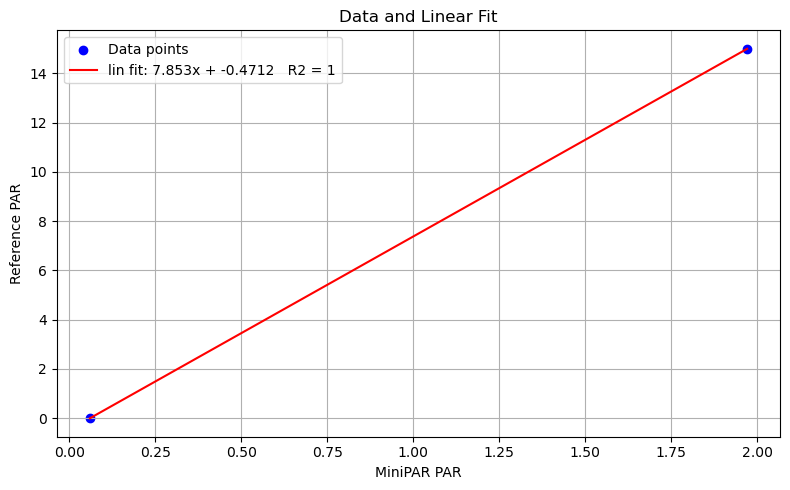

In [ ]:


y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)

plot_data_and_fit(x,y, coeffs, r2, xlabel="MiniPAR PAR", ylabel="Reference PAR")


 


In [77]:
# upload the calibration coefficient to the miniPAR
slope = coeffs[0]
offset = coeffs[1]
with serial.Serial(PORT_MINIPAR) as ser:
    ser.write(f"cal_par_slope,{slope:.6g}\n".encode())
    print(ser.readline())
    time.sleep(0.3)
    ser.write(f"cal_par_intercept,{offset:.6g}\n".encode())
    print(ser.readline())

b'{"calibration":{"slope":7.85}}\r\n'
b'{"calibration":{"intercept":-0.47}}\r\n'


In [78]:
print("Raw values:", get_par(PORT_MINIPAR, raw=True))
time.sleep(0.5) # otherwise might overcome serial 
print("Calibrated values:", get_par(PORT_MINIPAR, raw=False))


Raw values: 1.97
Calibrated values: 15.03


In [ ]:


set_MP_name(PORT_MINIPAR, name="miniPAR")
time.sleep(0.5)
print(get_MP_name(PORT_MINIPAR))


miniPAR
